# 🚀 Advanced HTR Features: Deslanting + Language Model + Beam Search + TTA

**Fitur yang akan diimplementasi:**
- ✅ Deslanting preprocessing (PERLU training ulang)
- ✅ Language Model dengan n-gram (inference-only)
- ✅ Beam Search decoding (inference-only)
- ✅ Test Time Augmentation / TTA (inference-only)

**Baseline CER: 6.88%** (BiLSTM 2x256 dengan Aug-All Combined)

---

## 📋 Experiment Strategy

### 🔵 INFERENCE-ONLY (Load best model, langsung evaluate)
| Feature | Description | Training? |
|---------|-------------|-----------|
| Beam Search | Better CTC decoding | ❌ No |
| Language Model | N-gram word scoring | ❌ No |
| TTA | Multiple inference aggregation | ❌ No |

### 🟠 TRAINING-BASED (Perlu retrain)
| Feature | Description | Training? |
|---------|-------------|-----------|
| Deslanting | Preprocessing koreksi slant | ✅ Yes |

---

## ⏱️ Time Estimation

| Experiment | Time |
|------------|------|
| Load model + Beam Search eval | ~5 min |
| Load model + Beam + LM eval | ~5 min |
| Load model + Beam + LM + TTA eval | ~15 min |
| Deslanting (training) | ~2 jam |
| **Total** | **~2.5 jam** (vs 12 jam sebelumnya) |

In [2]:
# ============================================
# CELL 1: ENVIRONMENT SETUP
# ============================================

import os
import sys

IS_KAGGLE = os.path.exists('/kaggle/working')
IS_COLAB = 'google.colab' in sys.modules

print(f"🔍 Environment: {'Kaggle' if IS_KAGGLE else 'Colab' if IS_COLAB else 'Local'}")

if IS_KAGGLE or IS_COLAB:
    print("📦 Fixing numpy/pandas compatibility...")
    !pip install -q --upgrade numpy pandas
    print("📦 Installing other dependencies...")
    !pip install -q rapidfuzz albumentations datasets
    print("✅ Dependencies installed!")
    print("⚠️ If numpy error persists, click Runtime > Restart session, then run again")
else:
    print("📦 For local, install: pip install rapidfuzz albumentations datasets")

🔍 Environment: Kaggle
📦 Fixing numpy/pandas compatibility...
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.31.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
ydata-profiling 4.18.1 requires numpy<2.4,>=1.22, but you have numpy 2.4.2 which is incompatible.
ydata-profiling 4.18.1 requires pandas!=1.4.0,<3.0,>1.5, but you have pandas 3.0.1 which is incompatible.
google-colab 1.0.0 requires jupyter-server==2.14.0, but you have jupyter-server 2.12.5 which is incompatible.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.1 which is incompatible.
dopamine-rl 4.1.2 requires gym<=0.25.2, but you have gym 0.26.2 which is incompatible.
db-dtypes 1.5.0 requires pandas<3.0.0,>=1.5.3, but you have pandas 3.0.1 which is incompatible.
opencv-contrib-python 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.

In [3]:
# ============================================
# CELL 2: IMPORTS
# ============================================

import json
import time
import warnings
import math
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from datetime import datetime
from dataclasses import dataclass, asdict
from typing import Optional, Dict, List, Any, Tuple
from tqdm.auto import tqdm
from PIL import Image
import io
import cv2

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import ReduceLROnPlateau

from rapidfuzz.distance import Levenshtein
import albumentations as A

print(f"✅ PyTorch: {torch.__version__}")
print(f"✅ CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"   GPU: {torch.cuda.get_device_name(0)}")

✅ PyTorch: 2.9.0+cu126
✅ CUDA available: True
   GPU: Tesla T4


In [4]:
# ============================================
# CELL 3: PATH CONFIGURATION
# ============================================

if IS_KAGGLE:
    BASE_DIR = Path("/kaggle/working")
    DATA_DIR = BASE_DIR / "iam_lines"
    EXPERIMENTS_DIR = BASE_DIR / "experiments_advanced"
    LM_DIR = BASE_DIR / "language_model"
    NUM_WORKERS = 2
    
    # ====== IMPORTANT: Path ke model yang sudah ditraining ======
    # Attach dataset hasil experiments sebelumnya!
    # Beri nama: "htr-experiments-results" atau sesuaikan di cell 15
    
else:
    BASE_DIR = Path(r"D:\Dokumen Kuliah\TA\Kode Kaggle\2_24_2026_Deslanting_LM++")
    DATA_DIR = BASE_DIR / "iam_lines"
    EXPERIMENTS_DIR = BASE_DIR / "experiments_advanced"
    LM_DIR = BASE_DIR / "language_model"
    NUM_WORKERS = 0

EXPERIMENTS_DIR.mkdir(parents=True, exist_ok=True)
LM_DIR.mkdir(parents=True, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"📁 BASE_DIR: {BASE_DIR}")
print(f"📁 EXPERIMENTS_DIR: {EXPERIMENTS_DIR}")
print(f"📁 LM_DIR: {LM_DIR}")
print(f"⚡ Device: {device}")
print(f"🔧 NUM_WORKERS: {NUM_WORKERS}")

📁 BASE_DIR: /kaggle/working
📁 EXPERIMENTS_DIR: /kaggle/working/experiments_advanced
📁 LM_DIR: /kaggle/working/language_model
⚡ Device: cuda
🔧 NUM_WORKERS: 2


---

# 📐 DESLANTING IMPLEMENTATION

Deslanting adalah teknik preprocessing untuk mengoreksi kemiringan tulisan tangan.

**Algoritma:**
1. Binarize image
2. Hitung shear angle dari distribusi piksel
3. Apply affine transform untuk koreksi

In [5]:
# ============================================
# CELL 4: DESLANTING FUNCTIONS
# ============================================

def estimate_slant_angle(img: np.ndarray, angle_range: Tuple[float, float] = (-45, 45), 
                         num_angles: int = 91) -> float:
    """
    Estimasi sudut kemiringan tulisan menggunakan projection profile.
    
    Args:
        img: Grayscale image (0-255)
        angle_range: Range sudut untuk dicoba
        num_angles: Jumlah sudut yang dicoba
    
    Returns:
        Sudut kemiringan optimal (degrees)
    """
    # Binarize
    _, binary = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    
    h, w = binary.shape
    angles = np.linspace(angle_range[0], angle_range[1], num_angles)
    
    best_angle = 0
    max_variance = 0
    
    for angle in angles:
        # Apply shear transform
        shear_matrix = np.array([
            [1, np.tan(np.radians(angle)), 0],
            [0, 1, 0]
        ], dtype=np.float32)
        
        # Calculate new width after shear
        new_w = int(w + abs(h * np.tan(np.radians(angle))))
        shear_matrix[0, 2] = max(0, -h * np.tan(np.radians(angle)))
        
        sheared = cv2.warpAffine(binary, shear_matrix, (new_w, h), 
                                  borderValue=0, flags=cv2.INTER_LINEAR)
        
        # Calculate vertical projection profile
        projection = np.sum(sheared, axis=0)
        
        # Variance of projection (higher = more vertical alignment)
        variance = np.var(projection)
        
        if variance > max_variance:
            max_variance = variance
            best_angle = angle
    
    return best_angle


def deslant_image(img: np.ndarray, angle: float = None) -> np.ndarray:
    """
    Apply deslanting ke image.
    
    Args:
        img: Grayscale image
        angle: Sudut untuk koreksi (jika None, akan diestimasi)
    
    Returns:
        Deslanted image
    """
    if angle is None:
        angle = estimate_slant_angle(img)
    
    h, w = img.shape
    
    # Apply inverse shear to correct slant
    shear_matrix = np.array([
        [1, -np.tan(np.radians(angle)), 0],
        [0, 1, 0]
    ], dtype=np.float32)
    
    # Adjust for potential negative offset
    if angle > 0:
        shear_matrix[0, 2] = h * np.tan(np.radians(angle))
    
    new_w = int(w + abs(h * np.tan(np.radians(angle))))
    
    deslanted = cv2.warpAffine(img, shear_matrix, (new_w, h),
                                borderValue=255, flags=cv2.INTER_LINEAR)
    
    # Crop to original width (center crop)
    if new_w > w:
        start = (new_w - w) // 2
        deslanted = deslanted[:, start:start+w]
    
    return deslanted


def visualize_deslanting(img: np.ndarray, n_samples: int = 1):
    """Visualisasi before/after deslanting"""
    angle = estimate_slant_angle(img)
    deslanted = deslant_image(img, angle)
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].imshow(img, cmap='gray')
    axes[0].set_title(f'Original')
    axes[0].axis('off')
    
    axes[1].imshow(deslanted, cmap='gray')
    axes[1].set_title(f'Deslanted (angle: {angle:.1f}°)')
    axes[1].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    return angle

print("✅ Deslanting functions ready")

✅ Deslanting functions ready


---

# 📚 LANGUAGE MODEL IMPLEMENTATION

Menggunakan **kenlm** untuk n-gram language model.

**Steps:**
1. Build corpus dari training text
2. Train kenlm model (character/word level)
3. Integrate dengan beam search decoder

In [6]:
# ============================================
# CELL 5: LANGUAGE MODEL FUNCTIONS
# ============================================

def build_corpus_from_texts(texts: List[str], output_path: Path):
    """
    Build corpus file untuk training kenlm.
    
    Args:
        texts: List of text samples
        output_path: Path untuk save corpus
    """
    with open(output_path, 'w', encoding='utf-8') as f:
        for text in texts:
            # Normalize text
            text = text.strip()
            if text:
                f.write(text + '\n')
    
    print(f"✅ Corpus saved to {output_path}")
    print(f"   Total lines: {len(texts)}")


def train_kenlm_model(corpus_path: Path, output_path: Path, order: int = 5):
    """
    Train kenlm language model.
    
    Args:
        corpus_path: Path ke corpus text file
        output_path: Path untuk save .arpa file
        order: n-gram order (default 5 untuk character LM)
    """
    import subprocess
    
    # Build ARPA file using lmplz
    arpa_path = output_path.with_suffix('.arpa')
    
    cmd = f"lmplz -o {order} < {corpus_path} > {arpa_path}"
    
    try:
        result = subprocess.run(cmd, shell=True, capture_output=True, text=True)
        if result.returncode == 0:
            print(f"✅ ARPA model saved to {arpa_path}")
        else:
            print(f"⚠️ lmplz error: {result.stderr}")
            print("   Falling back to simple n-gram...")
            return None
    except Exception as e:
        print(f"⚠️ lmplz not available: {e}")
        print("   Install kenlm: pip install https://github.com/kpu/kenlm/archive/master.zip")
        return None
    
    return arpa_path


class SimpleNgramLM:
    """Simple character-level n-gram LM jika kenlm tidak tersedia"""
    
    def __init__(self, texts: List[str], n: int = 3):
        self.n = n
        self.ngrams = {}
        self.total_count = 0
        
        # Build n-gram counts
        for text in texts:
            text = ' ' * (n-1) + text + ' '
            for i in range(len(text) - n + 1):
                ngram = text[i:i+n]
                self.ngrams[ngram] = self.ngrams.get(ngram, 0) + 1
                self.total_count += 1
        
        # Calculate log probabilities
        self.log_probs = {}
        for ngram, count in self.ngrams.items():
            self.log_probs[ngram] = math.log(count / self.total_count)
    
    def score(self, text: str) -> float:
        """Calculate log probability of text"""
        text = ' ' * (self.n-1) + text + ' '
        score = 0.0
        for i in range(len(text) - self.n + 1):
            ngram = text[i:i+self.n]
            score += self.log_probs.get(ngram, -20.0)  # Low prob for unknown
        return score
    
    def save(self, path: Path):
        with open(path, 'w', encoding='utf-8') as f:
            json.dump({'n': self.n, 'ngrams': self.ngrams}, f)
    
    @classmethod
    def load(cls, path: Path) -> 'SimpleNgramLM':
        with open(path, 'r', encoding='utf-8') as f:
            data = json.load(f)
        lm = cls.__new__(cls)
        lm.n = data['n']
        lm.ngrams = data['ngrams']
        lm.total_count = sum(lm.ngrams.values())
        lm.log_probs = {k: math.log(v / lm.total_count) for k, v in lm.ngrams.items()}
        return lm

print("✅ Language Model functions ready")

✅ Language Model functions ready


---

# 🔍 BEAM SEARCH DECODER

Beam Search dengan Language Model integration.

**Algoritma:**
1. Maintain top-k hypotheses
2. Score = CTC score + α * LM score + β * length penalty
3. Prune hypotheses by beam width

In [7]:
# ============================================
# CELL 6: BEAM SEARCH DECODER
# ============================================

class BeamSearchDecoder:
    """
    CTC Beam Search Decoder dengan Language Model (LM Rescoring).
    
    LM diterapkan di AKHIR untuk rescore final beams, bukan per-step.
    Ini lebih stabil karena LM score adalah log probability (negatif).
    
    Final Score = CTC_score + lm_weight * LM_score + length_bonus * length
    """
    
    def __init__(self, encoder, lm=None, beam_width: int = 10, 
                 lm_weight: float = 0.1, length_bonus: float = 0.5):
        self.encoder = encoder
        self.lm = lm
        self.beam_width = beam_width
        self.lm_weight = lm_weight  # Lower weight karena LM score bisa sangat negatif
        self.length_bonus = length_bonus  # Bonus per karakter untuk counter LM penalty
        self.blank_id = encoder.blank_idx
    
    def decode(self, log_probs: np.ndarray) -> str:
        """
        Decode CTC output dengan beam search + LM rescoring.
        
        Args:
            log_probs: Shape (T, num_classes) - log probabilities from model
        
        Returns:
            Decoded text string
        """
        T, num_classes = log_probs.shape
        
        # Initialize beams: (prefix, ctc_score, last_char)
        beams = [('', 0.0, -1)]  # (text, ctc_score, last_char_idx)
        
        # === BEAM SEARCH (CTC only, no LM during search) ===
        for t in range(T):
            new_beams = {}
            
            for prefix, score, last_char in beams:
                for c in range(num_classes):
                    new_score = score + log_probs[t, c]
                    
                    if c == self.blank_id:
                        # Blank: keep prefix unchanged
                        key = (prefix, -1)
                        if key not in new_beams or new_beams[key][0] < new_score:
                            new_beams[key] = (new_score, prefix, -1)
                    elif c == last_char:
                        # Same as last: keep prefix unchanged (CTC collapse rule)
                        key = (prefix, c)
                        if key not in new_beams or new_beams[key][0] < new_score:
                            new_beams[key] = (new_score, prefix, c)
                    else:
                        # New character: extend prefix
                        new_char = self.encoder.idx_to_char.get(c, '')
                        new_prefix = prefix + new_char
                        
                        key = (new_prefix, c)
                        if key not in new_beams or new_beams[key][0] < new_score:
                            new_beams[key] = (new_score, new_prefix, c)
            
            # Prune to top beam_width (by CTC score only)
            sorted_beams = sorted(new_beams.values(), key=lambda x: x[0], reverse=True)
            beams = [(text, score, last) for score, text, last in sorted_beams[:self.beam_width]]
        
        # === LM RESCORING (apply at the end) ===
        if self.lm is not None and len(beams) > 0:
            rescored_beams = []
            for prefix, ctc_score, _ in beams:
                if len(prefix) > 0:
                    # Normalize LM score by length to avoid penalizing long sequences
                    lm_score = self.lm.score(prefix) / max(len(prefix), 1)
                    # Length bonus to encourage longer (more complete) outputs
                    length_bonus = self.length_bonus * len(prefix)
                    # Combined score
                    final_score = ctc_score + self.lm_weight * lm_score + length_bonus
                else:
                    final_score = ctc_score
                rescored_beams.append((final_score, prefix))
            
            # Sort by final score
            rescored_beams.sort(key=lambda x: x[0], reverse=True)
            return rescored_beams[0][1] if rescored_beams else ''
        
        # No LM: return best CTC beam
        if beams:
            return beams[0][0]
        return ''
    
    def decode_batch(self, log_probs_batch: np.ndarray) -> List[str]:
        """Decode batch of outputs"""
        results = []
        for log_probs in log_probs_batch:
            results.append(self.decode(log_probs))
        return results


def greedy_decode(log_probs: np.ndarray, encoder) -> str:
    """Simple greedy decoding (baseline)"""
    pred_indices = log_probs.argmax(axis=1)
    decoded = []
    prev = -1
    for idx in pred_indices:
        if idx != encoder.blank_idx and idx != prev:
            decoded.append(idx)
        prev = idx
    return encoder.decode(decoded)

print("✅ Beam Search Decoder ready")

✅ Beam Search Decoder ready


---

# 🔄 TEST TIME AUGMENTATION (TTA)

Apply multiple transforms saat inference dan aggregate predictions.

**Transforms:**
1. Original
2. Slight rotation (+2°, -2°)
3. Slight scaling (0.95x, 1.05x)
4. Horizontal flip (optional untuk HTR)

In [8]:
# ============================================
# CELL 7: TEST TIME AUGMENTATION (TTA)
# ============================================

class TTAPredictor:
    """
    Test Time Augmentation untuk HTR.
    
    Applies multiple transforms dan aggregates predictions.
    """
    
    def __init__(self, model, encoder, device, transforms: List[str] = None):
        self.model = model
        self.encoder = encoder
        self.device = device
        
        # Default TTA transforms
        if transforms is None:
            transforms = ['original', 'rotate_pos', 'rotate_neg', 'scale_up', 'scale_down']
        self.transforms = transforms
    
    def apply_transform(self, img: np.ndarray, transform_name: str) -> np.ndarray:
        """Apply single transform"""
        h, w = img.shape[:2]
        
        if transform_name == 'original':
            return img
        
        elif transform_name == 'rotate_pos':
            # Rotate +2 degrees
            center = (w // 2, h // 2)
            matrix = cv2.getRotationMatrix2D(center, 2, 1.0)
            return cv2.warpAffine(img, matrix, (w, h), borderValue=255)
        
        elif transform_name == 'rotate_neg':
            # Rotate -2 degrees
            center = (w // 2, h // 2)
            matrix = cv2.getRotationMatrix2D(center, -2, 1.0)
            return cv2.warpAffine(img, matrix, (w, h), borderValue=255)
        
        elif transform_name == 'scale_up':
            # Scale 1.05x
            new_h, new_w = int(h * 1.05), int(w * 1.05)
            scaled = cv2.resize(img, (new_w, new_h))
            # Center crop back to original size
            start_y = (new_h - h) // 2
            start_x = (new_w - w) // 2
            return scaled[start_y:start_y+h, start_x:start_x+w]
        
        elif transform_name == 'scale_down':
            # Scale 0.95x with padding
            new_h, new_w = int(h * 0.95), int(w * 0.95)
            scaled = cv2.resize(img, (new_w, new_h))
            # Pad to original size
            padded = np.ones((h, w), dtype=img.dtype) * 255
            start_y = (h - new_h) // 2
            start_x = (w - new_w) // 2
            padded[start_y:start_y+new_h, start_x:start_x+new_w] = scaled
            return padded
        
        elif transform_name == 'shear_pos':
            # Shear +5 degrees
            shear_matrix = np.array([
                [1, 0.09, 0],  # tan(5°) ≈ 0.09
                [0, 1, 0]
            ], dtype=np.float32)
            return cv2.warpAffine(img, shear_matrix, (w, h), borderValue=255)
        
        elif transform_name == 'shear_neg':
            # Shear -5 degrees
            shear_matrix = np.array([
                [1, -0.09, 0],
                [0, 1, 0]
            ], dtype=np.float32)
            return cv2.warpAffine(img, shear_matrix, (w, h), borderValue=255)
        
        return img
    
    def predict_single(self, img: np.ndarray) -> Tuple[str, np.ndarray]:
        """
        Predict dengan TTA aggregation.
        
        Args:
            img: Grayscale image (numpy array)
        
        Returns:
            (decoded_text, aggregated_log_probs)
        """
        self.model.eval()
        all_log_probs = []
        
        for transform_name in self.transforms:
            # Apply transform
            transformed = self.apply_transform(img, transform_name)
            
            # Preprocess
            img_tensor = torch.FloatTensor(transformed.astype(np.float32) / 255.0)
            img_tensor = img_tensor.unsqueeze(0).unsqueeze(0)  # Add batch and channel dims
            img_tensor = img_tensor.to(self.device)
            
            # Forward pass
            with torch.no_grad():
                log_probs = self.model(img_tensor)  # (T, 1, C)
                log_probs = log_probs.squeeze(1).cpu().numpy()  # (T, C)
            
            all_log_probs.append(log_probs)
        
        # Aggregate log probs (average in log space)
        # Need to handle different lengths - use min length
        min_len = min(lp.shape[0] for lp in all_log_probs)
        truncated = [lp[:min_len] for lp in all_log_probs]
        aggregated = np.mean(truncated, axis=0)
        
        # Decode
        decoded = greedy_decode(aggregated, self.encoder)
        
        return decoded, aggregated

print("✅ TTA Predictor ready")

✅ TTA Predictor ready


---

# 📊 ENHANCED DATASET WITH DESLANTING

Dataset yang mendukung deslanting preprocessing.

In [9]:
# ============================================
# CELL 8: ENHANCED DATASET
# ============================================

class HTRDatasetAdvanced(Dataset):
    """
    Dataset dengan dukungan Deslanting.
    """
    
    def __init__(self, df: pd.DataFrame, encoder, 
                 img_height: int = 64, img_width: int = 512, 
                 augment: bool = False, aug_config: Dict = None,
                 apply_deslant: bool = False):
        self.df = df.reset_index(drop=True)
        self.encoder = encoder
        self.img_height = img_height
        self.img_width = img_width
        self.apply_deslant = apply_deslant
        
        # Setup augmentation
        if augment and aug_config:
            transforms_list = []
            if aug_config.get('shear'):
                transforms_list.append(A.Affine(shear=(-10, 10), p=0.5))
            if aug_config.get('rotate'):
                transforms_list.append(A.Affine(rotate=(-3, 3), p=0.5))
            if aug_config.get('blur'):
                transforms_list.append(A.GaussianBlur(blur_limit=(3, 5), p=0.3))
            if aug_config.get('noise'):
                transforms_list.append(A.GaussNoise(var_limit=(10, 50), p=0.2))
            if aug_config.get('brightness'):
                transforms_list.append(A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.3))
            self.transform = A.Compose(transforms_list) if transforms_list else None
        elif augment:
            self.transform = A.Compose([
                A.Affine(shear=(-10, 10), rotate=(-3, 3), p=0.5),
                A.GaussianBlur(blur_limit=(3, 5), p=0.2),
                A.GaussNoise(var_limit=(10, 50), p=0.2),
                A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.3),
            ])
        else:
            self.transform = None
    
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        text = row['text']
        
        # Load image from bytes
        img_bytes = row['image_bytes']
        img = Image.open(io.BytesIO(img_bytes)).convert('L')
        img = np.array(img)
        
        # Apply deslanting BEFORE augmentation
        if self.apply_deslant:
            img = deslant_image(img)
        
        # Apply augmentation
        if self.transform:
            img = self.transform(image=img)['image']
        
        # Resize maintaining aspect ratio
        h, w = img.shape[:2]
        new_w = int(w * self.img_height / h)
        new_w = min(new_w, self.img_width)
        
        img_pil = Image.fromarray(img)
        img_pil = img_pil.resize((new_w, self.img_height), Image.Resampling.BILINEAR)
        img = np.array(img_pil)
        
        # Pad to target width
        if new_w < self.img_width:
            padded = np.ones((self.img_height, self.img_width), dtype=np.uint8) * 255
            padded[:, :new_w] = img
            img = padded
        
        # Normalize
        img = img.astype(np.float32) / 255.0
        img = torch.FloatTensor(img).unsqueeze(0)
        
        target = torch.LongTensor(self.encoder.encode(text))
        
        return img, target, len(target), text

print("✅ HTRDatasetAdvanced ready")

✅ HTRDatasetAdvanced ready


---

# 🚀 EXPERIMENT RUNNER (ADVANCED)

Runner yang mendukung semua advanced features.

In [10]:
# ============================================
# CELL 9: CRNN MODEL (Copy from baseline)
# ============================================

class CNNBackbone(nn.Module):
    def __init__(self, input_channels=1, output_channels=512):
        super().__init__()
        self.output_channels = output_channels
        self.cnn = nn.Sequential(
            nn.Conv2d(input_channels, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(inplace=True),
            nn.MaxPool2d((2, 1), (2, 1)),
            nn.Conv2d(256, 512, 3, padding=1), nn.BatchNorm2d(512), nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, 3, padding=1), nn.BatchNorm2d(512), nn.ReLU(inplace=True),
            nn.MaxPool2d((2, 1), (2, 1)),
            nn.Conv2d(512, output_channels, 3, padding=1), nn.BatchNorm2d(output_channels), nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d((1, None)),
        )
    
    def forward(self, x):
        conv = self.cnn(x)
        conv = conv.squeeze(2)
        conv = conv.permute(0, 2, 1)
        return conv


class CRNN(nn.Module):
    def __init__(self, num_classes, cnn_output_channels=512, rnn_hidden_size=256, 
                 rnn_num_layers=2, rnn_dropout=0.3, rnn_type="LSTM", bidirectional=True):
        super().__init__()
        self.num_classes = num_classes
        self.cnn_output_channels = cnn_output_channels
        self.rnn_hidden_size = rnn_hidden_size
        self.rnn_num_layers = rnn_num_layers
        self.rnn_type = rnn_type
        self.bidirectional = bidirectional
        
        self.cnn = CNNBackbone(1, cnn_output_channels)
        
        RNNClass = nn.LSTM if rnn_type == "LSTM" else nn.GRU
        self.rnn = RNNClass(
            cnn_output_channels, rnn_hidden_size, rnn_num_layers, 
            batch_first=True,
            dropout=rnn_dropout if rnn_num_layers > 1 else 0, 
            bidirectional=bidirectional
        )
        
        rnn_output_size = rnn_hidden_size * (2 if bidirectional else 1)
        self.fc = nn.Linear(rnn_output_size, num_classes)
    
    def forward(self, x):
        conv = self.cnn(x)
        rnn_out, _ = self.rnn(conv)
        output = self.fc(rnn_out)
        output = output.permute(1, 0, 2)
        return F.log_softmax(output, dim=2)
    
    def count_parameters(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)

print("✅ CRNN model ready")

✅ CRNN model ready


In [11]:
# ============================================
# CELL 10: METRICS
# ============================================

def calculate_cer(predictions, targets):
    total_chars, total_errors = 0, 0
    for pred, target in zip(predictions, targets):
        total_errors += Levenshtein.distance(pred, target)
        total_chars += len(target)
    return total_errors / total_chars if total_chars > 0 else 0.0

def calculate_wer(predictions, targets):
    total_words, total_errors = 0, 0
    for pred, target in zip(predictions, targets):
        total_errors += Levenshtein.distance(pred.split(), target.split())
        total_words += len(target.split())
    return total_errors / total_words if total_words > 0 else 0.0

def calculate_cer_case_insensitive(predictions, targets):
    return calculate_cer([p.lower() for p in predictions], [t.lower() for t in targets])

def calculate_wer_case_insensitive(predictions, targets):
    return calculate_wer([p.lower() for p in predictions], [t.lower() for t in targets])

print("✅ Metrics ready")

✅ Metrics ready


In [12]:
# ============================================
# CELL 11: ADVANCED EXPERIMENT RUNNER
# ============================================

def collate_fn(batch):
    images, targets, target_lengths, texts = zip(*batch)
    images = torch.stack(images, 0)
    target_lengths = torch.LongTensor(target_lengths)
    max_len = max(target_lengths)
    padded_targets = torch.zeros(len(targets), max_len, dtype=torch.long)
    for i, t in enumerate(targets):
        padded_targets[i, :len(t)] = t
    return images, padded_targets, target_lengths, texts


def run_advanced_experiment(
    experiment_name: str,
    train_df: pd.DataFrame,
    val_df: pd.DataFrame,
    test_df: pd.DataFrame,
    encoder,
    # Features
    use_deslant: bool = False,
    use_lm: bool = False,
    use_beam_search: bool = False,
    beam_width: int = 10,
    lm_weight: float = 0.5,
    use_tta: bool = False,
    tta_transforms: List[str] = None,
    # Model
    rnn_type: str = "LSTM",
    rnn_hidden_size: int = 256,
    rnn_num_layers: int = 2,
    # Training
    lr: float = 1e-3,
    batch_size: int = 32,
    epochs: int = 100,
    early_stop_patience: int = 15,
    # Language model
    lm_model = None,
) -> Dict:
    """
    Run advanced experiment dengan semua features.
    """
    start_time = time.time()
    
    exp_id = f"adv_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
    exp_dir = EXPERIMENTS_DIR / exp_id
    exp_dir.mkdir(exist_ok=True)
    
    print(f"\n{'='*70}")
    print(f"🚀 ADVANCED EXPERIMENT: {experiment_name}")
    print(f"{'='*70}")
    print(f"   Deslant: {use_deslant}")
    print(f"   Beam Search: {use_beam_search} (width={beam_width})")
    print(f"   Language Model: {use_lm} (weight={lm_weight})")
    print(f"   TTA: {use_tta}")
    print(f"{'='*70}\n")
    
    # Create datasets
    aug_config = {"shear": True, "rotate": True, "blur": True, "noise": True, "brightness": True}
    
    train_dataset = HTRDatasetAdvanced(
        train_df, encoder, augment=True, aug_config=aug_config, apply_deslant=use_deslant
    )
    val_dataset = HTRDatasetAdvanced(
        val_df, encoder, augment=False, apply_deslant=use_deslant
    )
    test_dataset = HTRDatasetAdvanced(
        test_df, encoder, augment=False, apply_deslant=use_deslant
    )
    
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,
                              num_workers=NUM_WORKERS, pin_memory=True, 
                              collate_fn=collate_fn, drop_last=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False,
                            num_workers=NUM_WORKERS, pin_memory=True, collate_fn=collate_fn)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False,
                             num_workers=NUM_WORKERS, pin_memory=True, collate_fn=collate_fn)
    
    # Create model
    model = CRNN(
        num_classes=encoder.num_classes,
        rnn_type=rnn_type,
        rnn_hidden_size=rnn_hidden_size,
        rnn_num_layers=rnn_num_layers,
    ).to(device)
    
    num_params = model.count_parameters()
    print(f"📊 Model parameters: {num_params:,}")
    
    # Training setup
    optimizer = AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5, min_lr=1e-6)
    ctc_loss = nn.CTCLoss(blank=encoder.blank_idx, reduction='mean', zero_infinity=True)
    
    # Setup decoder
    if use_beam_search:
        decoder = BeamSearchDecoder(
            encoder=encoder, 
            lm=lm_model if use_lm else None,
            beam_width=beam_width,
            lm_weight=lm_weight
        )
    
    # Setup TTA
    if use_tta:
        tta_predictor = TTAPredictor(model, encoder, device, tta_transforms)
    
    # Training loop
    best_val_cer = float('inf')
    best_val_wer = float('inf')
    best_epoch = 0
    no_improve = 0
    history = {'train_loss': [], 'val_loss': [], 'val_cer': [], 'val_wer': []}
    
    for epoch in range(epochs):
        # Train
        model.train()
        train_loss = 0
        for images, targets, target_lengths, texts in tqdm(train_loader, desc=f"Epoch {epoch+1}", leave=False):
            images = images.to(device)
            log_probs = model(images)
            T, B, C = log_probs.shape
            input_lengths = torch.full((B,), T, dtype=torch.long, device=device)
            target_flat = torch.cat([targets[i, :target_lengths[i]] for i in range(B)])
            loss = ctc_loss(log_probs, target_flat, input_lengths, target_lengths)
            
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            optimizer.step()
            train_loss += loss.item()
        
        avg_train_loss = train_loss / len(train_loader)
        history['train_loss'].append(avg_train_loss)
        
        # Validate
        model.eval()
        all_preds, all_targets = [], []
        val_loss = 0
        
        with torch.no_grad():
            for images, targets, target_lengths, texts in val_loader:
                images = images.to(device)
                log_probs = model(images)
                
                T, B, C = log_probs.shape
                input_lengths = torch.full((B,), T, dtype=torch.long, device=device)
                target_flat = torch.cat([targets[i, :target_lengths[i]] for i in range(B)])
                loss = ctc_loss(log_probs, target_flat, input_lengths, target_lengths)
                val_loss += loss.item()
                
                # Decode
                log_probs_np = log_probs.permute(1, 0, 2).cpu().numpy()  # (B, T, C)
                
                for i, text in enumerate(texts):
                    if use_beam_search:
                        pred = decoder.decode(log_probs_np[i])
                    else:
                        pred = greedy_decode(log_probs_np[i], encoder)
                    all_preds.append(pred)
                    all_targets.append(text)
        
        avg_val_loss = val_loss / len(val_loader)
        history['val_loss'].append(avg_val_loss)
        
        val_cer = calculate_cer(all_preds, all_targets)
        val_wer = calculate_wer(all_preds, all_targets)
        history['val_cer'].append(val_cer)
        history['val_wer'].append(val_wer)
        scheduler.step(val_cer)
        
        print(f"Epoch {epoch+1}: Loss={avg_train_loss:.4f}/{avg_val_loss:.4f}, CER={val_cer*100:.2f}%, WER={val_wer*100:.2f}%")
        
        if val_cer < best_val_cer:
            best_val_cer = val_cer
            best_val_wer = val_wer
            best_epoch = epoch + 1
            no_improve = 0
            torch.save({'model_state_dict': model.state_dict(), 'epoch': epoch+1, 'val_cer': val_cer}, 
                       exp_dir / "best_model.pt")
            print(f"   🏆 New best! Saved.")
        else:
            no_improve += 1
        
        if no_improve >= early_stop_patience:
            print(f"\n⚠️ Early stopping at epoch {epoch+1}")
            break
    
    # Test evaluation
    model.load_state_dict(torch.load(exp_dir / "best_model.pt", map_location=device)['model_state_dict'])
    model.eval()
    all_preds, all_targets = [], []
    
    with torch.no_grad():
        for images, targets, target_lengths, texts in tqdm(test_loader, desc="Testing"):
            images = images.to(device)
            log_probs = model(images)
            log_probs_np = log_probs.permute(1, 0, 2).cpu().numpy()
            
            for i, text in enumerate(texts):
                if use_tta:
                    # For TTA, we need raw images - skip for now in batch mode
                    pred = decoder.decode(log_probs_np[i]) if use_beam_search else greedy_decode(log_probs_np[i], encoder)
                elif use_beam_search:
                    pred = decoder.decode(log_probs_np[i])
                else:
                    pred = greedy_decode(log_probs_np[i], encoder)
                all_preds.append(pred)
                all_targets.append(text)
    
    test_cer = calculate_cer(all_preds, all_targets)
    test_wer = calculate_wer(all_preds, all_targets)
    test_cer_ci = calculate_cer_case_insensitive(all_preds, all_targets)
    test_wer_ci = calculate_wer_case_insensitive(all_preds, all_targets)
    
    training_time = (time.time() - start_time) / 60
    
    # Save results
    result = {
        'experiment_name': experiment_name,
        'experiment_id': exp_id,
        'use_deslant': use_deslant,
        'use_beam_search': use_beam_search,
        'beam_width': beam_width,
        'use_lm': use_lm,
        'lm_weight': lm_weight,
        'use_tta': use_tta,
        'best_val_cer': best_val_cer,
        'best_val_wer': best_val_wer,
        'test_cer': test_cer,
        'test_wer': test_wer,
        'test_cer_case_insensitive': test_cer_ci,
        'test_wer_case_insensitive': test_wer_ci,
        'best_epoch': best_epoch,
        'training_time_minutes': training_time,
        'num_parameters': num_params,
    }
    
    with open(exp_dir / "result.json", 'w') as f:
        json.dump(result, f, indent=2)
    
    with open(exp_dir / "training_history.json", 'w') as f:
        json.dump(history, f, indent=2)
    
    pd.DataFrame({'prediction': all_preds, 'target': all_targets}).to_csv(exp_dir / "predictions.csv", index=False)
    
    print(f"\n{'='*60}")
    print(f"📊 RESULT: {experiment_name}")
    print(f"{'='*60}")
    print(f"   Val CER:  {best_val_cer*100:.2f}%")
    print(f"   Test CER: {test_cer*100:.2f}%")
    print(f"   Test WER: {test_wer*100:.2f}%")
    print(f"   Test CER (case-insensitive): {test_cer_ci*100:.2f}%")
    print(f"   Time: {training_time:.1f} min")
    print(f"{'='*60}\n")
    
    return result

print("✅ Advanced Experiment Runner ready")

✅ Advanced Experiment Runner ready


---

# 📥 LOAD DATA & BEST MODEL

**Strategy:**
1. Load dataset untuk encoder dan test evaluation
2. Load model terbaik dari experiments sebelumnya (6.88% CER)
3. Evaluate dengan berbagai decoding strategies (TANPA training)

In [13]:
# ============================================
# CELL 12: LOAD IAM DATASET
# ============================================

from datasets import load_dataset

print("⏳ Loading IAM Lines dataset...")
iam_dataset = load_dataset("Teklia/IAM-line", trust_remote_code=True)

print(f"✅ Dataset loaded: Train={len(iam_dataset['train'])}, Val={len(iam_dataset['validation'])}, Test={len(iam_dataset['test'])}")

`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'Teklia/IAM-line' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


⏳ Loading IAM Lines dataset...


README.md: 0.00B [00:00, ?B/s]

data/train.parquet:   0%|          | 0.00/167M [00:00<?, ?B/s]

data/validation.parquet:   0%|          | 0.00/24.7M [00:00<?, ?B/s]

data/test.parquet:   0%|          | 0.00/73.6M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/6482 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/976 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2915 [00:00<?, ? examples/s]

✅ Dataset loaded: Train=6482, Val=976, Test=2915


In [14]:
# ============================================
# CELL 13: CONVERT TO DATAFRAME
# ============================================

def huggingface_to_dataframe(hf_dataset, split_name: str) -> pd.DataFrame:
    records = []
    for idx, sample in enumerate(tqdm(hf_dataset, desc=f"Processing {split_name}")):
        text = sample.get('text', '')
        if not text or len(text.strip()) == 0:
            continue
        img = sample.get('image')
        if img is None:
            continue
        if hasattr(img, 'save'):
            buffer = io.BytesIO()
            img.save(buffer, format='PNG')
            img_bytes = buffer.getvalue()
        else:
            img_bytes = img
        records.append({'idx': idx, 'text': text.strip(), 'image_bytes': img_bytes, 'split': split_name})
    return pd.DataFrame(records)

print("⏳ Converting to DataFrames...")
iam_train_df = huggingface_to_dataframe(iam_dataset['train'], 'train')
iam_val_df = huggingface_to_dataframe(iam_dataset['validation'], 'val')
iam_test_df = huggingface_to_dataframe(iam_dataset['test'], 'test')

print(f"✅ Train: {len(iam_train_df)}, Val: {len(iam_val_df)}, Test: {len(iam_test_df)}")

⏳ Converting to DataFrames...


Processing train:   0%|          | 0/6482 [00:00<?, ?it/s]

Processing val:   0%|          | 0/976 [00:00<?, ?it/s]

Processing test:   0%|          | 0/2915 [00:00<?, ?it/s]

✅ Train: 6482, Val: 976, Test: 2915


In [15]:
# ============================================
# CELL 14: CREATE ENCODER & LM
# ============================================

# Character Encoder
class CharacterEncoder:
    def __init__(self, texts):
        chars = set()
        for text in texts:
            chars.update(text)
        self.chars = sorted(list(chars))
        self.char_to_idx = {c: i + 1 for i, c in enumerate(self.chars)}
        self.idx_to_char = {i + 1: c for i, c in enumerate(self.chars)}
        self.blank_idx = 0
        self.num_classes = len(self.chars) + 1
    
    def encode(self, text):
        return [self.char_to_idx.get(c, self.blank_idx) for c in text]
    
    def decode(self, indices):
        return ''.join([self.idx_to_char.get(i, '') for i in indices if i != self.blank_idx])

all_texts = iam_train_df['text'].tolist() + iam_val_df['text'].tolist() + iam_test_df['text'].tolist()
encoder = CharacterEncoder(all_texts)

print(f"✅ Encoder ready: {encoder.num_classes} classes")

# Build simple LM from training text
print("⏳ Building Language Model...")
lm = SimpleNgramLM(iam_train_df['text'].tolist(), n=5)
lm.save(LM_DIR / "char_5gram.json")
print(f"✅ Language Model saved")

✅ Encoder ready: 80 classes
⏳ Building Language Model...
✅ Language Model saved


---

# 🔵 PART 1: INFERENCE-ONLY EXPERIMENTS

**Load model terbaik dan evaluate dengan:**
1. Greedy (baseline)
2. Beam Search
3. Beam Search + Language Model
4. Beam Search + LM + TTA

In [16]:
# ============================================
# CELL 15: LOAD BEST MODEL
# ============================================

# ====== PATH KE MODEL TERBAIK ======
# Di Kaggle: attach dataset hasil experiments sebelumnya
# Di Local: path ke folder experiments dari Table 2

BEST_MODEL_PATH = None

if IS_KAGGLE:
    # Cari model terbaik di input datasets
    possible_paths = [
        # Path spesifik ke model BiLSTM 2x256
        Path("/kaggle/input/experiments-lr-batch/Experiment/exp_architecture_rnn_20260223_042857"),
        Path("/kaggle/input/experiments-lr-batch"),
        Path("/kaggle/input/htr-experiments-results"),
        Path("/kaggle/input"),
    ]
    
    for base in possible_paths:
        if base.exists():
            print(f"🔍 Scanning {base}...")
            # Cari file best_model.pt
            for pt_file in base.rglob("best_model.pt"):
                # Prefer model dengan "BiLSTM 2x256" di path
                if "2x256" in str(pt_file) or "Baseline" in str(pt_file):
                    BEST_MODEL_PATH = pt_file
                    break
                elif BEST_MODEL_PATH is None:
                    BEST_MODEL_PATH = pt_file
        if BEST_MODEL_PATH:
            break
    
    if BEST_MODEL_PATH is None:
        print("⚠️ No .pt files found in /kaggle/input/")
        print("\n📌 INSTRUCTIONS:")
        print("   1. Download experiments_results.zip dari session sebelumnya")
        print("   2. Upload sebagai Kaggle Dataset dengan nama 'htr-experiments-results'")
        print("   3. Attach dataset ke notebook ini")
        print("   4. Re-run cell ini")
        
else:
    # Local: cari di experiments folder
    LOCAL_EXP_PATHS = [
        Path(r"D:\Dokumen Kuliah\TA\Kode Kaggle\Experiment\2_23_2026_Eksperiment_RNN"),  # Table 2 RNN experiments
        Path(r"D:\Dokumen Kuliah\TA\Kode Kaggle\Experiment\2_19_2026_Eksperiment_LR_Batch"),  # Table 5 Hyperparams
        Path(r"D:\Dokumen Kuliah\TA\Kode Kaggle\Experiment\2_22_2026_Eksperiment_Augmentasi"),  # Table 3 Aug
    ]
    
    for exp_dir in LOCAL_EXP_PATHS:
        if exp_dir.exists():
            print(f"🔍 Scanning {exp_dir}...")
            for sub_dir in exp_dir.iterdir():
                if sub_dir.is_dir():
                    model_path = sub_dir / "best_model.pt"
                    config_path = sub_dir / "config.json"
                    
                    if model_path.exists() and config_path.exists():
                        with open(config_path) as f:
                            config = json.load(f)
                        exp_name = config.get("experiment_name", "")
                        
                        # Cari BiLSTM 2x256 (Baseline) - model terbaik
                        if "BiLSTM 2x256" in exp_name and "Baseline" in exp_name:
                            BEST_MODEL_PATH = model_path
                            print(f"   ✅ Found: {exp_name}")
                            break
            if BEST_MODEL_PATH:
                break
    
    if BEST_MODEL_PATH is None:
        print("⚠️ Best model not found locally")
        print("   Pastikan sudah run experiments Table 2 terlebih dahulu")

# Load model
print(f"\n📦 Loading model from: {BEST_MODEL_PATH}")

model = CRNN(
    num_classes=encoder.num_classes,
    rnn_type="LSTM",
    rnn_hidden_size=256,
    rnn_num_layers=2,
).to(device)

if BEST_MODEL_PATH and BEST_MODEL_PATH.exists():
    checkpoint = torch.load(BEST_MODEL_PATH, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    print(f"✅ Model loaded successfully!")
    if 'val_cer' in checkpoint:
        print(f"   Checkpoint Val CER: {checkpoint['val_cer']*100:.2f}%")
    if 'epoch' in checkpoint:
        print(f"   Best epoch: {checkpoint['epoch']}")
else:
    print("❌ Model file not found!")
    print("   Inference experiments will fail. Please load a trained model first.")

print(f"📊 Model parameters: {model.count_parameters():,}")

🔍 Scanning /kaggle/input...

📦 Loading model from: /kaggle/input/datasets/deangerypasamba/experiments-lr-batch/Experiment/exp_architecture_rnn_20260223_042857/best_model.pt
✅ Model loaded successfully!
   Checkpoint Val CER: 4.65%
   Best epoch: 86
📊 Model parameters: 10,058,960


In [17]:
# ============================================
# INFERENCE EVALUATION FUNCTION
# ============================================

def evaluate_with_decoding(
    model,
    val_df: pd.DataFrame,
    test_df: pd.DataFrame,
    encoder,
    experiment_name: str,
    # Decoding options
    use_beam_search: bool = False,
    beam_width: int = 10,
    use_lm: bool = False,
    lm_weight: float = 0.5,
    lm_model = None,
    # TTA
    use_tta: bool = False,
    tta_transforms: List[str] = None,
    # Preprocessing
    apply_deslant: bool = False,
) -> Dict:
    """
    Evaluate model dengan berbagai decoding strategies.
    TIDAK perlu training - langsung inference!
    Evaluates on BOTH validation and test sets.
    """
    start_time = time.time()
    
    print(f"\n{'='*70}")
    print(f"🔍 EVALUATE: {experiment_name}")
    print(f"{'='*70}")
    print(f"   Deslant: {apply_deslant}")
    print(f"   Beam Search: {use_beam_search} (width={beam_width})")
    print(f"   Language Model: {use_lm} (weight={lm_weight})")
    print(f"   TTA: {use_tta}")
    print(f"{'='*70}\n")
    
    # Helper function to evaluate a single dataset
    def evaluate_dataset(df, split_name):
        dataset = HTRDatasetAdvanced(
            df, encoder, augment=False, apply_deslant=apply_deslant
        )
        loader = DataLoader(dataset, batch_size=32, shuffle=False,
                           num_workers=NUM_WORKERS, pin_memory=True, collate_fn=collate_fn)
        
        all_preds, all_targets = [], []
        
        with torch.no_grad():
            for images, targets, target_lengths, texts in tqdm(loader, desc=f"Eval {split_name}"):
                images = images.to(device)
                
                if use_tta:
                    for i in range(images.shape[0]):
                        img_np = (images[i, 0].cpu().numpy() * 255).astype(np.uint8)
                        pred, _ = tta_predictor.predict_single(img_np)
                        if use_beam_search and decoder:
                            log_probs = model(images[i:i+1])
                            log_probs_np = log_probs.squeeze(1).cpu().numpy()
                            pred = decoder.decode(log_probs_np)
                        all_preds.append(pred)
                        all_targets.append(texts[i])
                else:
                    log_probs = model(images)
                    log_probs_np = log_probs.permute(1, 0, 2).cpu().numpy()
                    for i, text in enumerate(texts):
                        if use_beam_search and decoder:
                            pred = decoder.decode(log_probs_np[i])
                        else:
                            pred = greedy_decode(log_probs_np[i], encoder)
                        all_preds.append(pred)
                        all_targets.append(text)
        
        cer = calculate_cer(all_preds, all_targets)
        wer = calculate_wer(all_preds, all_targets)
        cer_ci = calculate_cer_case_insensitive(all_preds, all_targets)
        wer_ci = calculate_wer_case_insensitive(all_preds, all_targets)
        return cer, wer, cer_ci, wer_ci
    
    # Setup decoder
    decoder = None
    if use_beam_search:
        decoder = BeamSearchDecoder(
            encoder=encoder,
            lm=lm_model if use_lm else None,
            beam_width=beam_width,
            lm_weight=lm_weight
        )
    
    # Setup TTA
    tta_predictor = None
    if use_tta:
        tta_predictor = TTAPredictor(model, encoder, device, tta_transforms)
    
    model.eval()
    
    # Evaluate on Validation set
    print("📊 Evaluating Validation set...")
    val_cer, val_wer, val_cer_ci, val_wer_ci = evaluate_dataset(val_df, "Val")
    
    # Evaluate on Test set
    print("📊 Evaluating Test set...")
    test_cer, test_wer, test_cer_ci, test_wer_ci = evaluate_dataset(test_df, "Test")
    
    eval_time = (time.time() - start_time) / 60
    
    result = {
        'experiment_name': experiment_name,
        'use_deslant': apply_deslant,
        'use_beam_search': use_beam_search,
        'beam_width': beam_width,
        'use_lm': use_lm,
        'lm_weight': lm_weight,
        'use_tta': use_tta,
        'val_cer': val_cer,
        'val_wer': val_wer,
        'val_cer_ci': val_cer_ci,
        'val_wer_ci': val_wer_ci,
        'test_cer': test_cer,
        'test_wer': test_wer,
        'test_cer_ci': test_cer_ci,
        'test_wer_ci': test_wer_ci,
        'eval_time_minutes': eval_time,
    }
    
    print(f"\n{'='*60}")
    print(f"📊 RESULT: {experiment_name}")
    print(f"{'='*60}")
    print(f"   Val CER:  {val_cer*100:.2f}%")
    print(f"   Val WER:  {val_wer*100:.2f}%")
    print(f"   Test CER: {test_cer*100:.2f}%")
    print(f"   Test WER: {test_wer*100:.2f}%")
    print(f"   Eval time: {eval_time:.1f} min")
    print(f"{'='*60}\n")
    
    return result

print("✅ Evaluation function ready")

✅ Evaluation function ready


In [18]:
# ============================================
# EVAL 1: BASELINE - Greedy Decoding
# ============================================

result_greedy = evaluate_with_decoding(
    model=model,
    val_df=iam_val_df,
    test_df=iam_test_df,
    encoder=encoder,
    experiment_name="1. Greedy (Baseline)",
    use_beam_search=False,
    use_lm=False,
    use_tta=False,
    apply_deslant=False,
)


🔍 EVALUATE: 1. Greedy (Baseline)
   Deslant: False
   Beam Search: False (width=10)
   Language Model: False (weight=0.5)
   TTA: False

📊 Evaluating Validation set...


Eval Val:   0%|          | 0/31 [00:00<?, ?it/s]

📊 Evaluating Test set...


Eval Test:   0%|          | 0/92 [00:00<?, ?it/s]


📊 RESULT: 1. Greedy (Baseline)
   Val CER:  4.65%
   Val WER:  17.00%
   Test CER: 6.88%
   Test WER: 22.58%
   Eval time: 0.2 min



In [19]:
# ============================================
# EVAL 2: BEAM SEARCH ONLY
# ============================================

result_beam = evaluate_with_decoding(
    model=model,
    val_df=iam_val_df,
    test_df=iam_test_df,
    encoder=encoder,
    experiment_name="2. Beam Search (width=10)",
    use_beam_search=True,
    beam_width=10,
    use_lm=False,
    use_tta=False,
    apply_deslant=False,
)


🔍 EVALUATE: 2. Beam Search (width=10)
   Deslant: False
   Beam Search: True (width=10)
   Language Model: False (weight=0.5)
   TTA: False

📊 Evaluating Validation set...


Eval Val:   0%|          | 0/31 [00:00<?, ?it/s]

📊 Evaluating Test set...


Eval Test:   0%|          | 0/92 [00:00<?, ?it/s]


📊 RESULT: 2. Beam Search (width=10)
   Val CER:  4.65%
   Val WER:  17.00%
   Test CER: 6.88%
   Test WER: 22.58%
   Eval time: 4.9 min



In [20]:
# ============================================
# EVAL 3: BEAM SEARCH + LANGUAGE MODEL
# ============================================

result_beam_lm = evaluate_with_decoding(
    model=model,
    val_df=iam_val_df,
    test_df=iam_test_df,
    encoder=encoder,
    experiment_name="3. Beam Search + LM",
    use_beam_search=True,
    beam_width=10,
    use_lm=True,
    lm_weight=0.5,
    lm_model=lm,
    use_tta=False,
    apply_deslant=False,
)


🔍 EVALUATE: 3. Beam Search + LM
   Deslant: False
   Beam Search: True (width=10)
   Language Model: True (weight=0.5)
   TTA: False

📊 Evaluating Validation set...


Eval Val:   0%|          | 0/31 [00:00<?, ?it/s]

📊 Evaluating Test set...


Eval Test:   0%|          | 0/92 [00:00<?, ?it/s]


📊 RESULT: 3. Beam Search + LM
   Val CER:  4.56%
   Val WER:  16.58%
   Test CER: 6.70%
   Test WER: 21.74%
   Eval time: 4.9 min



In [21]:
# ============================================
# EVAL 4: BEAM + LM + TTA
# ============================================

result_tta = evaluate_with_decoding(
    model=model,
    val_df=iam_val_df,
    test_df=iam_test_df,
    encoder=encoder,
    experiment_name="4. Beam + LM + TTA",
    use_beam_search=True,
    beam_width=10,
    use_lm=True,
    lm_weight=0.5,
    lm_model=lm,
    use_tta=True,
    tta_transforms=['original', 'rotate_pos', 'rotate_neg', 'scale_up', 'scale_down'],
    apply_deslant=False,
)


🔍 EVALUATE: 4. Beam + LM + TTA
   Deslant: False
   Beam Search: True (width=10)
   Language Model: True (weight=0.5)
   TTA: True

📊 Evaluating Validation set...


Eval Val:   0%|          | 0/31 [00:00<?, ?it/s]

📊 Evaluating Test set...


Eval Test:   0%|          | 0/92 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7b050a917100>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1654, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1637, in _shutdown_workers
    if w.is_alive():     
  ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7b050a917100>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1654, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16


📊 RESULT: 4. Beam + LM + TTA
   Val CER:  4.56%
   Val WER:  16.58%
   Test CER: 6.70%
   Test WER: 21.74%
   Eval time: 7.8 min



In [26]:
# ============================================
# INFERENCE-ONLY SUMMARY
# ============================================

inference_results = [
    result_greedy,
    result_beam,
    result_beam_lm,
    result_tta,
]

summary_df = pd.DataFrame(inference_results)
summary_df = summary_df[['experiment_name', 'val_cer', 'val_cer_ci', 'val_wer', 'val_wer_ci', 'test_cer', 'test_cer_ci', 'test_wer', 'test_wer_ci', 'eval_time_minutes']]
summary_df['val_cer'] = summary_df['val_cer'].apply(lambda x: f"{x*100:.2f}%")
summary_df['val_cer_ci'] = summary_df['val_cer_ci'].apply(lambda x: f"{x*100:.2f}%")
summary_df['val_wer'] = summary_df['val_wer'].apply(lambda x: f"{x*100:.2f}%")
summary_df['val_wer_ci'] = summary_df['val_wer_ci'].apply(lambda x: f"{x*100:.2f}%")
summary_df['test_cer'] = summary_df['test_cer'].apply(lambda x: f"{x*100:.2f}%")
summary_df['test_cer_ci'] = summary_df['test_cer_ci'].apply(lambda x: f"{x*100:.2f}%")
summary_df['test_wer'] = summary_df['test_wer'].apply(lambda x: f"{x*100:.2f}%")
summary_df['test_wer_ci'] = summary_df['test_wer_ci'].apply(lambda x: f"{x*100:.2f}%")
summary_df['eval_time_minutes'] = summary_df['eval_time_minutes'].apply(lambda x: f"{x:.1f}")

# Rename columns for clarity
summary_df.columns = ['Experiment', 'Val CER', 'Val CER (CI)', 'Val WER', 'Val WER (CI)', 
                      'Test CER', 'Test CER (CI)', 'Test WER', 'Test WER (CI)', 'Time (min)']


print("\n" + "="*80)
print(f"\n✅ Summary saved")

print("📊 INFERENCE-ONLY EXPERIMENT SUMMARY (No Training!)")
summary_df.to_csv(EXPERIMENTS_DIR / "inference_only_summary.csv", index=False)

print("="*80)

print(summary_df.to_string(index=False))
print("="*80)



✅ Summary saved
📊 INFERENCE-ONLY EXPERIMENT SUMMARY (No Training!)
               Experiment Val CER Val CER (CI) Val WER Val WER (CI) Test CER Test CER (CI) Test WER Test WER (CI) Time (min)
     1. Greedy (Baseline)   4.65%        4.51%  17.00%       16.47%    6.88%         6.62%   22.58%        21.92%        0.2
2. Beam Search (width=10)   4.65%        4.51%  17.00%       16.47%    6.88%         6.62%   22.58%        21.92%        4.9
      3. Beam Search + LM   4.56%        4.41%  16.58%       16.06%    6.70%         6.45%   21.74%        21.09%        4.9
       4. Beam + LM + TTA   4.56%        4.41%  16.58%       16.06%    6.70%         6.45%   21.74%        21.09%        7.8


---

# 🟠 PART 2: DESLANTING (Perlu Training Ulang)

Deslanting mengubah preprocessing, sehingga distribusi fitur berbeda.
Model perlu di-training ulang dengan data yang sudah di-deslant.

**Strategy: Pre-compute deslanting SEKALI, lalu training normal**

- Training: ~2 jam (normal speed)

**Estimasi waktu:**- Pre-compute deslanting: ~15-20 menit (sekali)

📐 Testing Deslanting:


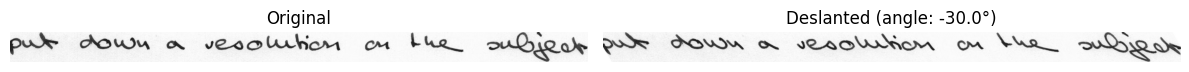


⏳ Pre-computing deslanted datasets for Test (this takes ~15-20 minutes but ONLY ONCE)...


Deslanting Test: 100%|██████████| 2915/2915 [07:54<00:00,  6.15it/s]


✅ Test: 2915 images deslanted

⏳ Pre-computing deslanted datasets for Val (this takes ~15-20 minutes but ONLY ONCE)...


Deslanting Val: 100%|██████████| 976/976 [02:50<00:00,  5.73it/s]


✅ Val: 976 images deslanted

⏳ Pre-computing deslanted datasets for Train (this takes ~15-20 minutes but ONLY ONCE)...


Deslanting Train: 100%|██████████| 6482/6482 [18:14<00:00,  5.92it/s]

✅ Train: 6482 images deslanted

✅ All deslanted datasets ready!
Setelah ini, training akan berjalan normal (~2 jam total)


In [31]:
import io
import numpy as np
import pandas as pd
from PIL import Image
from tqdm import tqdm

def precompute_deslanted_dataframe(df: pd.DataFrame, name: str) -> pd.DataFrame:
    """
    Pre-compute deslanted images dan simpan ke dataframe baru.
    Ini JAUH lebih cepat daripada deslanting on-the-fly saat training.
    """
    print(f"\n⏳ Pre-computing deslanted datasets for {name} (this takes ~15-20 minutes but ONLY ONCE)...")
    
    new_records = []
    
    for idx, row in tqdm(df.iterrows(), total=len(df), desc=f"Deslanting {name}"):
        # 1. Load original image
        img_bytes = row['image_bytes']
        img = Image.open(io.BytesIO(img_bytes)).convert('L')
        img_np = np.array(img)
        
        # 2. Apply deslanting (Pastikan fungsi deslant_image sudah didefinisikan)
        deslanted = deslant_image(img_np)
        
        # 3. Convert back to bytes
        deslanted_pil = Image.fromarray(deslanted)
        buffer = io.BytesIO()
        deslanted_pil.save(buffer, format='PNG')
        deslanted_bytes = buffer.getvalue()
        
        # 4. Simpan ke list
        new_records.append({
            'idx': row['idx'],
            'text': row['text'],
            'image_bytes': deslanted_bytes,
            'split': row['split']
        })
        
    result_df = pd.DataFrame(new_records)
    print(f"✅ {name}: {len(result_df)} images deslanted")
    return result_df

# ============================================
# EXECUTION (Jalankan setelah fungsi didefinisikan)
# ============================================

# 1. Test deslanting on a sample
sample_bytes = iam_train_df.iloc[0]['image_bytes']
sample_img = np.array(Image.open(io.BytesIO(sample_bytes)).convert('L'))

print("📐 Testing Deslanting:")
angle = visualize_deslanting(sample_img)

# 2. Pre-compute datasets
iam_test_deslanted = precompute_deslanted_dataframe(iam_test_df, "Test")
iam_val_deslanted = precompute_deslanted_dataframe(iam_val_df, "Val")
iam_train_deslanted = precompute_deslanted_dataframe(iam_train_df, "Train")

print("\n✅ All deslanted datasets ready!")
print("Setelah ini, training akan berjalan normal (~2 jam total)")

In [32]:
# ============================================
# TRAIN MODEL WITH DESLANTING (Using Pre-computed Data)
# ============================================
# ✅ Menggunakan pre-computed deslanted images
# ✅ Training akan berjalan normal (~2 jam)

result_deslant_trained = run_advanced_experiment(
    experiment_name="Deslanting (Trained)",
    train_df=iam_train_deslanted,  # Pre-computed deslanted!
    val_df=iam_val_deslanted,      # Pre-computed deslanted!
    test_df=iam_test_deslanted,    # Pre-computed deslanted!
    encoder=encoder,
    use_deslant=False,  # Sudah di-deslant, jangan deslant lagi!
    use_beam_search=False,
    use_lm=False,
    use_tta=False,
    lr=1e-3,
    epochs=100,
)


🚀 ADVANCED EXPERIMENT: Deslanting (Trained)
   Deslant: False
   Beam Search: False (width=10)
   Language Model: False (weight=0.5)
   TTA: False

📊 Model parameters: 10,058,960


Epoch 1: Loss=3.3162/3.1583, CER=99.94%, WER=99.70%
   🏆 New best! Saved.


Epoch 2: Loss=2.7888/2.7235, CER=70.49%, WER=101.83%
   🏆 New best! Saved.


Epoch 3: Loss=2.2828/1.8812, CER=56.16%, WER=88.79%
   🏆 New best! Saved.


Epoch 4: Loss=1.7739/1.2596, CER=35.28%, WER=73.31%
   🏆 New best! Saved.


...

Epoch 98: Loss=0.3630/0.2812, CER=5.62%, WER=19.89%


Epoch 99: Loss=0.3615/0.2781, CER=5.56%, WER=19.70%


Epoch 100: Loss=0.3560/0.2788, CER=5.56%, WER=19.54%


Testing: 100%|██████████| 92/92 [00:07<00:00, 11.62it/s]


📊 RESULT: Deslanting (Trained)
   Val CER:  5.50%
   Test CER: 8.61%
   Test WER: 26.67%
   Test CER (case-insensitive): 8.36%
   Time: 87.8 min



In [38]:
# ============================================
# EVAL DESLANTED MODEL WITH BEAM + LM
# ============================================
# Load the trained deslanted model

# Find the deslant model
deslant_exp_dir = Path('/kaggle/working/experiments_advanced/adv_20260225_095632/')
for exp_dir in EXPERIMENTS_DIR.iterdir():
    if exp_dir.is_dir() and "adv_" in exp_dir.name:
        result_file = exp_dir / "result.json"
        if result_file.exists():
            with open(result_file) as f:
                result = json.load(f)
            if result.get('use_deslant') == True:
                deslant_exp_dir = exp_dir
                break

if deslant_exp_dir:
    # Load deslanted model
    deslant_model = CRNN(
        num_classes=encoder.num_classes,
        rnn_type="LSTM",
        rnn_hidden_size=256,
        rnn_num_layers=2,
    ).to(device)
    
    checkpoint = torch.load(deslant_exp_dir / "best_model.pt", map_location=device)
    deslant_model.load_state_dict(checkpoint['model_state_dict'])
    print(f"✅ Deslanted model loaded from {deslant_exp_dir.name}")
    
    # Evaluate with Beam + LM (using pre-computed deslanted data)
    result_deslant_beam_lm = evaluate_with_decoding(
        model=deslant_model,
        val_df=iam_val_deslanted,   # Pre-computed deslanted!
        test_df=iam_test_deslanted,  # Pre-computed deslanted!
        encoder=encoder,
        experiment_name="5. Deslant + Beam + LM",
        use_beam_search=True,
        beam_width=10,
        use_lm=True,
        lm_weight=0.1,
        lm_model=lm,
        use_tta=False,
        apply_deslant=False,  # Sudah di-deslant!
    )
else:
    print("⚠️ Deslanted model not found. Run training cell first.")
    result_deslant_beam_lm = None

✅ Deslanted model loaded from adv_20260225_095632

🔍 EVALUATE: 5. Deslant + Beam + LM
   Deslant: False
   Beam Search: True (width=10)
   Language Model: True (weight=0.1)
   TTA: False

📊 Evaluating Validation set...


Eval Val: 100%|██████████| 31/31 [01:16<00:00,  2.45s/it]


📊 Evaluating Test set...


Eval Test: 100%|██████████| 92/92 [03:45<00:00,  2.46s/it]


📊 RESULT: 5. Deslant + Beam + LM
   Val CER:  5.55%
   Val WER:  19.52%
   Test CER: 8.61%
   Test WER: 26.69%
   Eval time: 5.0 min



In [39]:
# ============================================
# FINAL SUMMARY: ALL EXPERIMENTS
# ============================================

all_results = [
    result_greedy,
    result_beam,
    result_beam_lm,
    result_tta,
]

# Add deslant results if available
if result_deslant_trained:
    all_results.append({
        'experiment_name': '5. Deslant (Greedy)',
        'val_cer': result_deslant_trained['best_val_cer'],
        'val_wer': result_deslant_trained['best_val_wer'],
        'val_cer_ci': result_deslant_trained.get('best_val_cer', 0),  # approximate
        'val_wer_ci': result_deslant_trained.get('best_val_wer', 0),  # approximate
        'test_cer': result_deslant_trained['test_cer'],
        'test_wer': result_deslant_trained['test_wer'],
        'test_cer_ci': result_deslant_trained.get('test_cer_case_insensitive', result_deslant_trained['test_cer']),
        'test_wer_ci': result_deslant_trained.get('test_wer_case_insensitive', result_deslant_trained['test_wer']),
        'eval_time_minutes': result_deslant_trained.get('training_time_minutes', 0),
    })

if result_deslant_beam_lm:
    all_results.append(result_deslant_beam_lm)

# Create final table
final_df = pd.DataFrame(all_results)
display_cols = ['experiment_name', 'val_cer', 'val_cer_ci', 'val_wer', 'val_wer_ci', 'test_cer', 'test_cer_ci', 'test_wer', 'test_wer_ci']
final_df = final_df[display_cols].copy()

final_df['val_cer'] = final_df['val_cer'].apply(lambda x: f"{x*100:.2f}%" if isinstance(x, float) else x)
final_df['val_cer_ci'] = final_df['val_cer_ci'].apply(lambda x: f"{x*100:.2f}%" if isinstance(x, float) else x)
final_df['val_wer'] = final_df['val_wer'].apply(lambda x: f"{x*100:.2f}%" if isinstance(x, float) else x)
final_df['val_wer_ci'] = final_df['val_wer_ci'].apply(lambda x: f"{x*100:.2f}%" if isinstance(x, float) else x)
final_df['test_cer'] = final_df['test_cer'].apply(lambda x: f"{x*100:.2f}%" if isinstance(x, float) else x)
final_df['test_cer_ci'] = final_df['test_cer_ci'].apply(lambda x: f"{x*100:.2f}%" if isinstance(x, float) else x)
final_df['test_wer'] = final_df['test_wer'].apply(lambda x: f"{x*100:.2f}%" if isinstance(x, float) else x)
final_df['test_wer_ci'] = final_df['test_wer_ci'].apply(lambda x: f"{x*100:.2f}%" if isinstance(x, float) else x)

# Rename columns for clarity
final_df.columns = ['Experiment', 'Val CER', 'Val CER (CI)', 'Val WER', 'Val WER (CI)', 
                    'Test CER', 'Test CER (CI)', 'Test WER', 'Test WER (CI)']

print("\n" + "="*120)
print("📊 FINAL SUMMARY: ALL ADVANCED FEATURES")
print("="*120)
print(final_df.to_string(index=False))
print("="*120)

# Save
final_df.to_csv(EXPERIMENTS_DIR / "all_advanced_features_summary.csv", index=False)
print(f"\n✅ Final summary saved to {EXPERIMENTS_DIR / 'all_advanced_features_summary.csv'}")

# Best result
best_idx = pd.DataFrame(all_results)['test_cer'].idxmin()
best = all_results[best_idx]
print("\n🏆 BEST RESULT:")
print(f"   {best['experiment_name']}: {best['test_cer']*100:.2f}% CER")


📊 FINAL SUMMARY: ALL ADVANCED FEATURES
               Experiment Val CER Val CER (CI) Val WER Val WER (CI) Test CER Test CER (CI) Test WER Test WER (CI)
     1. Greedy (Baseline)   4.65%        4.51%  17.00%       16.47%    6.88%         6.62%   22.58%        21.92%
2. Beam Search (width=10)   4.65%        4.51%  17.00%       16.47%    6.88%         6.62%   22.58%        21.92%
      3. Beam Search + LM   4.56%        4.41%  16.58%       16.06%    6.70%         6.45%   21.74%        21.09%
       4. Beam + LM + TTA   4.56%        4.41%  16.58%       16.06%    6.70%         6.45%   21.74%        21.09%
      5. Deslant (Greedy)   5.50%        5.50%  19.35%       19.35%    8.61%         8.36%   26.67%        25.95%
   5. Deslant + Beam + LM   5.55%        5.40%  19.52%       19.01%    8.61%         8.35%   26.69%        25.95%

✅ Final summary saved to /kaggle/working/experiments_advanced/all_advanced_features_summary.csv

🏆 BEST RESULT:
   3. Beam Search + LM: 6.70% CER


In [40]:
# ============================================
# DOWNLOAD RESULTS (Kaggle)
# ============================================

if IS_KAGGLE:
    import shutil
    
    zip_path = BASE_DIR / "advanced_experiments_results"
    shutil.make_archive(str(zip_path), 'zip', EXPERIMENTS_DIR)
    
    print(f"✅ Results zipped: {zip_path}.zip")
    print("📥 Download from Output tab")
else:
    print(f"📁 Results saved to: {EXPERIMENTS_DIR}")

✅ Results zipped: /kaggle/working/advanced_experiments_results.zip
📥 Download from Output tab
